In [15]:
!pip install yfinance -q
import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt

df = yf.download("AAPL", start="2018-01-01", end="2026-09-30", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232376,40.241720,39.531708,39.741910,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412212,40.514978,40.190335,40.297769,89738400
2018-01-05,40.872318,40.958733,40.416885,40.507971,94640000
2018-01-08,40.720505,41.014784,40.622408,40.720505,82271200


In [9]:
df.to_csv("AAPL_2018_2026.csv")
from google.colab import files
files.download("AAPL_2018_2026.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
df.describe()

Price,Close,High,Low,Open,Volume,Target
count,2196.000000,2196.000000,2196.000000,2196.000000,2.196000e+03,2196.000000
mean,148.098177,149.600987,146.444421,147.945508,9.063045e+07,148.229856
std,77.183173,77.896920,76.372273,77.078201,5.400291e+07,77.245707
min,33.707920,34.544750,33.662878,34.132260,1.791060e+07,33.707920
25%,70.824636,72.307694,69.636353,71.048627,5.203025e+07,71.392492
50%,147.403481,148.596507,145.335758,146.807743,7.635050e+07,147.452431
75%,199.719742,201.759886,197.480560,199.627688,1.116471e+08,199.921265
max,341.070007,345.339996,338.750000,341.079987,4.265100e+08,341.070007


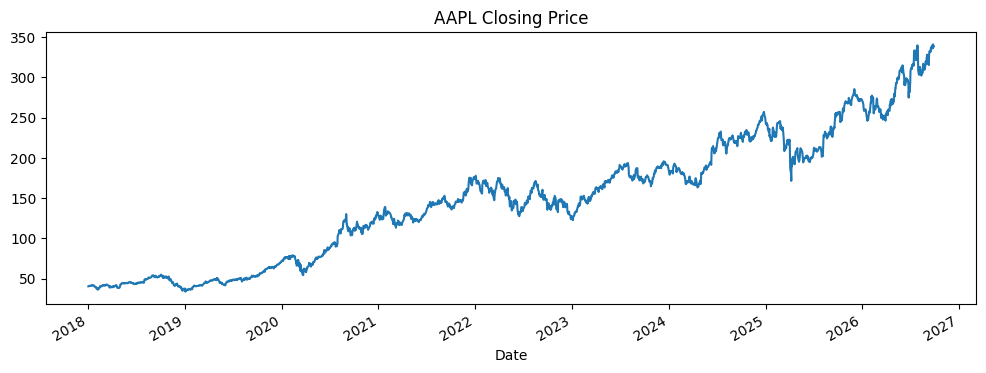

In [20]:
df["Close"].plot(figsize=(12, 4), title="AAPL Closing Price")
plt.show()

In [21]:
df["Target"] = df["Close"].shift(-1)   # next day's close
df = df.dropna()
X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Target"]
df.to_csv("AAPL_2018_2026.csv")   # saves the snapshot used in this project (2,196 rows incl. Target)

In [22]:
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 1756 | Test rows: 439


In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

MAE : 3.1972940072450418
RMSE: 4.642751211921456
R2  : 0.9860498121644552


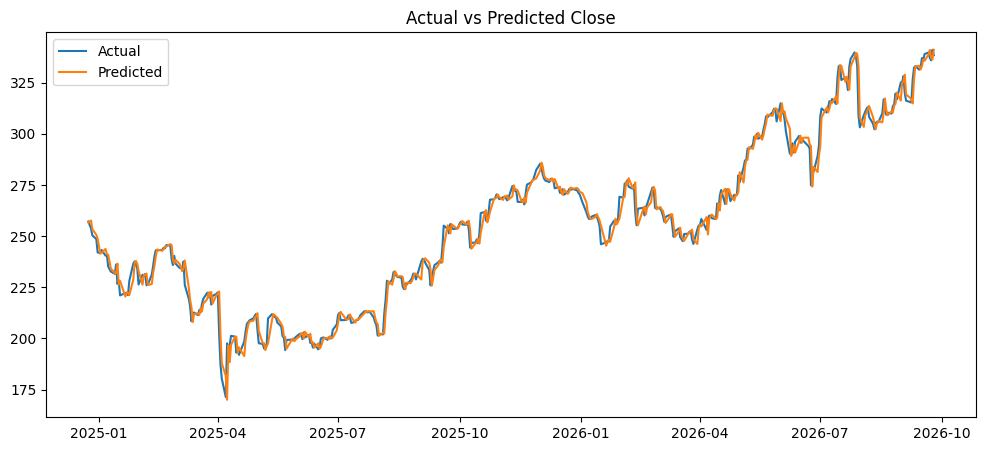

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.legend(); plt.title("Actual vs Predicted Close"); plt.show()

In [26]:
naive_pred = X_test["Close"]
print("Naive MAE :", mean_absolute_error(y_test, naive_pred))
print("Naive RMSE:", np.sqrt(mean_squared_error(y_test, naive_pred)))
print("Naive R2  :", r2_score(y_test, naive_pred))

Naive MAE : 3.124604731322964
Naive RMSE: 4.553219687608998
Naive R2  : 0.9865826594995802
